<a href="https://colab.research.google.com/github/haldarAryan/Facial-Biometrics-Encryption-Using-Henon-Ricker-Hybrid-Chaotic-Maps/blob/main/FaceDetectionTPE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install mtcnn dlib ultralytics
!pip install -q dlib
!pip install -q retina-face
!pip install -q pycryptodome

!pip install -q mtcnn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 99.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 85.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 90.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 99.3 MB/s eta 0:00:00


Mounted at /content/drive


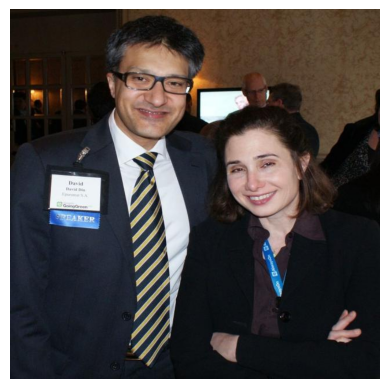

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os
from google.colab import drive

# 1. Mount the Drive
drive.mount('/content/drive')

# 2. Set the path
image_path = "/content/drive/MyDrive/valid5/images/IMG.jpg"

# 3. Read and Display
if os.path.exists(image_path):
    img = cv2.imread(image_path)
    # Convert BGR (OpenCV default) to RGB (Display default)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img_rgb)
    plt.axis("off")
    plt.show()
else:
    print(f"File not found: {image_path}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 31.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 85.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 28.4 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:04<00:00, 57210.79KB/s]


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
Processing 1

  0%|          | 0/1 [00:00<?, ?it/s]


[ANALYSIS] File: IMG.jpg
  > Face 1 Structure:
    - Bounding Box : [371, 211, 497, 359]
    - Dimensions   : 126px x 148px (Ratio: 0.85)
    - Landmarks    : Eyes: [[394, 277], [447, 269]], Nose: [419, 308]
  > Face 2 Structure:
    - Bounding Box : [184, 61, 309, 222]
    - Dimensions   : 125px x 161px (Ratio: 0.78)
    - Landmarks    : Eyes: [[227, 120], [284, 128]], Nose: [256, 163]
  > Face 3 Structure:
    - Bounding Box : [409, 120, 444, 170]
    - Dimensions   : 35px x 49px (Ratio: 0.71)
    - Landmarks    : Eyes: [[419, 143], [434, 140]], Nose: [427, 152]
  > Face 4 Structure:
    - Bounding Box : [442, 142, 469, 188]
    - Dimensions   : 26px x 46px (Ratio: 0.58)
    - Landmarks    : Eyes: [[447, 159], [448, 159]], Nose: [442, 166]
------------------------------


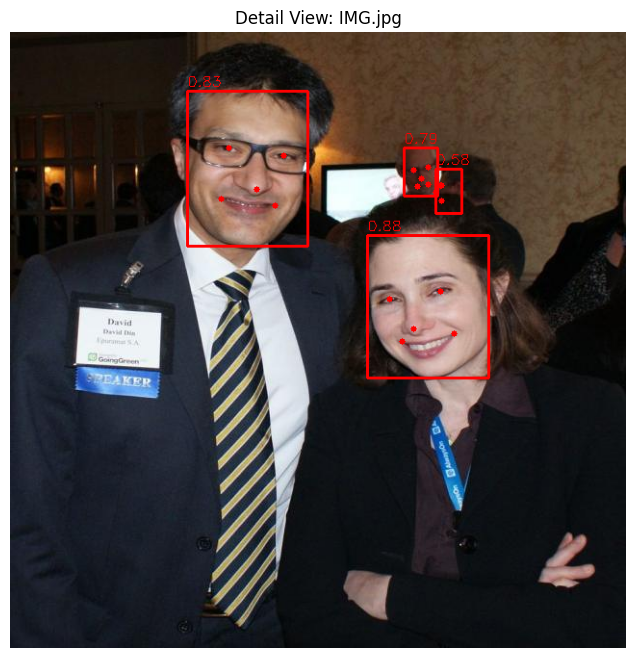

100%|██████████| 1/1 [00:02<00:00,  2.44s/it]


Final Evaluation Results:
mAP@0.5: 0.0000
mAP@0.5:0.95: 0.0000


In [ ]:
# =========================================================
# 1. INSTALLATION & ENVIRONMENT SETUP
# =========================================================
!pip install -q insightface onnxruntime opencv-python-headless matplotlib numpy tqdm

import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from google.colab import drive
from insightface.app import FaceAnalysis

# Connects Colab to your Drive
drive.mount('/content/drive')

# =========================================================
# 2. DATASET PATHS & MODEL INITIALIZATION
# =========================================================
images_path = '/content/drive/MyDrive/valid5/images'
labels_path = '/content/drive/MyDrive/valid5/labels'

# Initialize the RetinaFace (Buffalo_L) detector.
app = FaceAnalysis(name="buffalo_l", providers=["CPUExecutionProvider"])
app.prepare(ctx_id=0, det_size=(640, 640))

# =========================================================
# 3. GEOMETRIC & PARSING UTILITIES
# =========================================================
def compute_iou(box1, box2):
    """Calculates Intersection over Union (IoU) for mAP engine."""
    x1, y1 = max(box1[0], box2[0]), max(box1[1], box2[1])
    x2, y2 = min(box1[2], box2[2]), min(box1[3], box2[3])

    inter_w = max(0, x2 - x1)
    inter_h = max(0, y2 - y1)
    inter_area = inter_w * inter_h
    if inter_area <= 0: return 0.0

    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    return inter_area / (area1 + area2 - inter_area)

def load_yolo_labels(label_path, img_w, img_h):
    """Converts YOLO normalized labels to absolute pixel coordinates."""
    boxes = []
    if not os.path.exists(label_path): return boxes
    with open(label_path) as f:
        for line in f:
            _, x, y, w, h = map(float, line.split())
            x1 = (x - w / 2) * img_w
            y1 = (y - h / 2) * img_h
            x2 = (x + w / 2) * img_w
            y2 = (y + h / 2) * img_h
            boxes.append([x1, y1, x2, y2])
    return boxes

def print_face_structure(img_name, faces):
    """Prints structural metadata of detected face boxes."""
    print(f"\n[ANALYSIS] File: {img_name}")
    for i, face in enumerate(faces):
        x1, y1, x2, y2 = face.bbox
        w, h = x2 - x1, y2 - y1
        print(f"  > Face {i+1} Structure:")
        print(f"    - Bounding Box : [{int(x1)}, {int(y1)}, {int(x2)}, {int(y2)}]")
        print(f"    - Dimensions   : {int(w)}px x {int(h)}px (Ratio: {w/h:.2f})")
        if face.kps is not None:
            print(f"    - Landmarks    : Eyes: {face.kps[0:2].astype(int).tolist()}, Nose: {face.kps[2].astype(int).tolist()}")
    print("-" * 30)

def visualize_detailed(img_rgb, gt_boxes, faces, title):
    """Visualizes GT boxes, Prediction boxes, and Facial Landmarks."""
    img_vis = img_rgb.copy()
    # Ground Truth: Green
    for x1, y1, x2, y2 in gt_boxes:
        cv2.rectangle(img_vis, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)

    # Detections: Blue + Red Landmarks
    for face in faces:
        x1, y1, x2, y2 = face.bbox.astype(int)
        cv2.rectangle(img_vis, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(img_vis, f"{face.det_score:.2f}", (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 1)

        # Draw 5-point landmarks (Red)
        if face.kps is not None:
            for kp in face.kps:
                cv2.circle(img_vis, (int(kp[0]), int(kp[1])), 3, (255, 0, 0), -1)

    plt.figure(figsize=(10, 8))
    plt.imshow(img_vis); plt.axis("off"); plt.title(title); plt.show()

# =========================================================
# 4. EXECUTION & EVALUATION
# =========================================================
iou_thresholds = np.arange(0.5, 1.0, 0.05)
all_detections, all_confidences, all_gts = [], [], []

image_files = sorted(f for f in os.listdir(images_path) if f.lower().endswith(('.jpg','.png','.jpeg')))
VISUALIZE_LIMIT, vis_count = 5, 0

print(f"Processing {len(image_files)} images...")

for img_name in tqdm(image_files):
    img_path = os.path.join(images_path, img_name)
    label_path = os.path.join(labels_path, os.path.splitext(img_name)[0] + '.txt')

    img = cv2.imread(img_path)
    if img is None: continue
    h, w = img.shape[:2]
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    gt_boxes = load_yolo_labels(label_path, w, h)
    faces = app.get(img_rgb)

    if vis_count < VISUALIZE_LIMIT:
        print_face_structure(img_name, faces)
        visualize_detailed(img_rgb, gt_boxes, faces, f"Detail View: {img_name}")
        vis_count += 1

    # Silently collect data for metrics
    for face in faces:
        all_detections.append(face.bbox)
        all_confidences.append(face.det_score)
        all_gts.append(gt_boxes)

# =========================================================
# 5. mAP CALCULATION
# =========================================================
def compute_ap(rec, prec):
    return sum(max(prec[rec >= t], default=0) for t in np.arange(0, 1.1, 0.1)) / 11

mAPs = []
for t in iou_thresholds:
    TP, FP, scores = [], [], []
    n_gt = 0
    for box, conf, gts in zip(all_detections, all_confidences, all_gts):
        if not gts:
            TP.append(0); FP.append(1)
        else:
            best_iou = max(compute_iou(box, gt) for gt in gts)
            TP.append(int(best_iou >= t))
            FP.append(int(best_iou < t))
        scores.append(conf)
        n_gt += len(gts)

    idx = np.argsort(-np.array(scores))
    TP, FP = np.array(TP)[idx], np.array(FP)[idx]
    rec = np.cumsum(TP) / (n_gt + 1e-6)
    prec = np.cumsum(TP) / (np.cumsum(TP + FP) + 1e-6)
    mAPs.append(compute_ap(rec, prec))

print(f"\nFinal Evaluation Results:")
print(f"mAP@0.5: {mAPs[0]:.4f}")
print(f"mAP@0.5:0.95: {np.mean(mAPs):.4f}")

In [ ]:
# =========================================================
# PART 1: BIOMETRIC LOCALIZATION AND EXTRACTION
# =========================================================
# This script identifies the Facial ROI (Region of Interest)
# using RetinaFace and exports cropped biometric manifolds.
# =========================================================

import cv2
import os
import numpy as np
from tqdm import tqdm
from google.colab import drive
from insightface.app import FaceAnalysis

# Mount storage to persist dataset across sessions
drive.mount('/content/drive')
images_path = '/content/drive/MyDrive/valid5/images'
output_faces_path = '/content/drive/MyDrive/valid5/detected_faces'
os.makedirs(output_faces_path, exist_ok=True)

# Initialize RetinaFace (Buffalo_L)
# The backbone performs multi-stage detection (Localization -> Alignment)
app = FaceAnalysis(name="buffalo_l", providers=["CPUExecutionProvider"])
app.prepare(ctx_id=0, det_size=(640, 640))

image_files = sorted(f for f in os.listdir(images_path) if f.lower().endswith(('.jpg','.png','.jpeg')))

face_counter = 1
print(f"Extracting faces from {len(image_files)} images...")

for img_name in tqdm(image_files):
    img_path = os.path.join(images_path, img_name)
    img = cv2.imread(img_path)
    if img is None: continue

    # Convert BGR (OpenCV) to RGB (InsightFace) for correct inference
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    faces = app.get(img_rgb)

    if faces:
        for face in faces:
            # bbox: The detected bounding box coordinates [x1, y1, x2, y2]
            x1, y1, x2, y2 = face.bbox.astype(int)

            # Boundary check: Ensures the box stays within image dimensions
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(img.shape[1], x2), min(img.shape[0], y2)

            # Manifold Extraction: Slicing the numpy array to isolate the face
            face_crop = img[y1:y2, x1:x2]

            # Sequential naming for standardized dataset indexing
            face_save_name = f"face_{face_counter}.jpg"
            cv2.imwrite(os.path.join(output_faces_path, face_save_name), face_crop)

            face_counter += 1
    else:
        continue

print(f"\n✅ Done! {face_counter - 1} faces saved.")

# =========================================================
# PART 2: TPE PRE-PROCESSING & INVARIANT ANALYSIS
# =========================================================
# This script demonstrates the core principle of TPE:
# The Sum-Invariance of blocks to preserve visual utility.
# =========================================================

import cv2
import os
import numpy as np
from tqdm import tqdm

input_folder = '/content/drive/MyDrive/valid5/detected_faces'

# Filter directory for extracted biometric files
face_files = sorted([f for f in os.listdir(input_folder) if f.startswith('face_') and f.lower().endswith(('.jpg', '.png', '.jpeg'))])

print(f"Found {len(face_files)} face images to process.\n")

for face_name in face_files:
    face_path = os.path.join(input_folder, face_name)
    img = cv2.imread(face_path)

    if img is not None:
        # Step A: Normalization
        # Resizing to 256x256 ensures compatibility with block-based encryption
        resized_img = cv2.resize(img, (256, 256), interpolation=cv2.INTER_AREA)

        print(f"-----------------------------------------------------------")
        print(f"IMAGE: {face_name} | Target Size: 256x256")

        # Step B: Demonstration of Thumbnail Invariant (Block Summation)
        # TPE works by scrambling pixels while keeping the BLOCK SUM constant.
        # This constant sum ensures the 'average color' is preserved for thumbnails.

        block_size = 4

        # Extracting the origin block (0,0) for structural analysis
        first_block = resized_img[0:block_size, 0:block_size]

        # Calculate Sum: Summing across (0,1) axes isolates total channel intensity
        # B, G, R order is standard for OpenCV
        block_sum = np.sum(first_block, axis=(0, 1))

        print(f"First 4x4 Block Sum (B, G, R): {block_sum}")
        print(f"Key Concept: Scrambling inside this block must preserve this sum.")
        print(f"-----------------------------------------------------------\n")

    else:
        print(f"Skipping {face_name}: Could not load image.")

print("✅ Finished processing all faces.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root

100%|██████████| 1/1 [00:05<00:00,  5.12s/it]


✅ Done! 4 faces saved.
Found 4 face images to process.

-----------------------------------------------------------
IMAGE: face_1.jpg | Target Size: 256x256
First 4x4 Block Sum (B, G, R): [140 252 304]
Key Concept: Scrambling inside this block must preserve this sum.
-----------------------------------------------------------

-----------------------------------------------------------
IMAGE: face_2.jpg | Target Size: 256x256
First 4x4 Block Sum (B, G, R): [300 290 266]
Key Concept: Scrambling inside this block must preserve this sum.
-----------------------------------------------------------

-----------------------------------------------------------
IMAGE: face_3.jpg | Target Size: 256x256
First 4x4 Block Sum (B, G, R): [ 240  480 1104]
Key Concept: Scrambling inside this block must preserve this sum.
-----------------------------------------------------------

-----------------------------------------------------------
IMAGE: face_4.jpg | Target Size: 256x256
First 4x4 Block Sum 

<>:93: SyntaxWarning: invalid escape sequence '\m'
<>:93: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_11324/494101947.py:93: SyntaxWarning: invalid escape sequence '\m'
  titles = ["Block $B$", "Mean $\mu$", "Residuals $R$", " Shuffled Residual $R'$", " Result $B'$"]


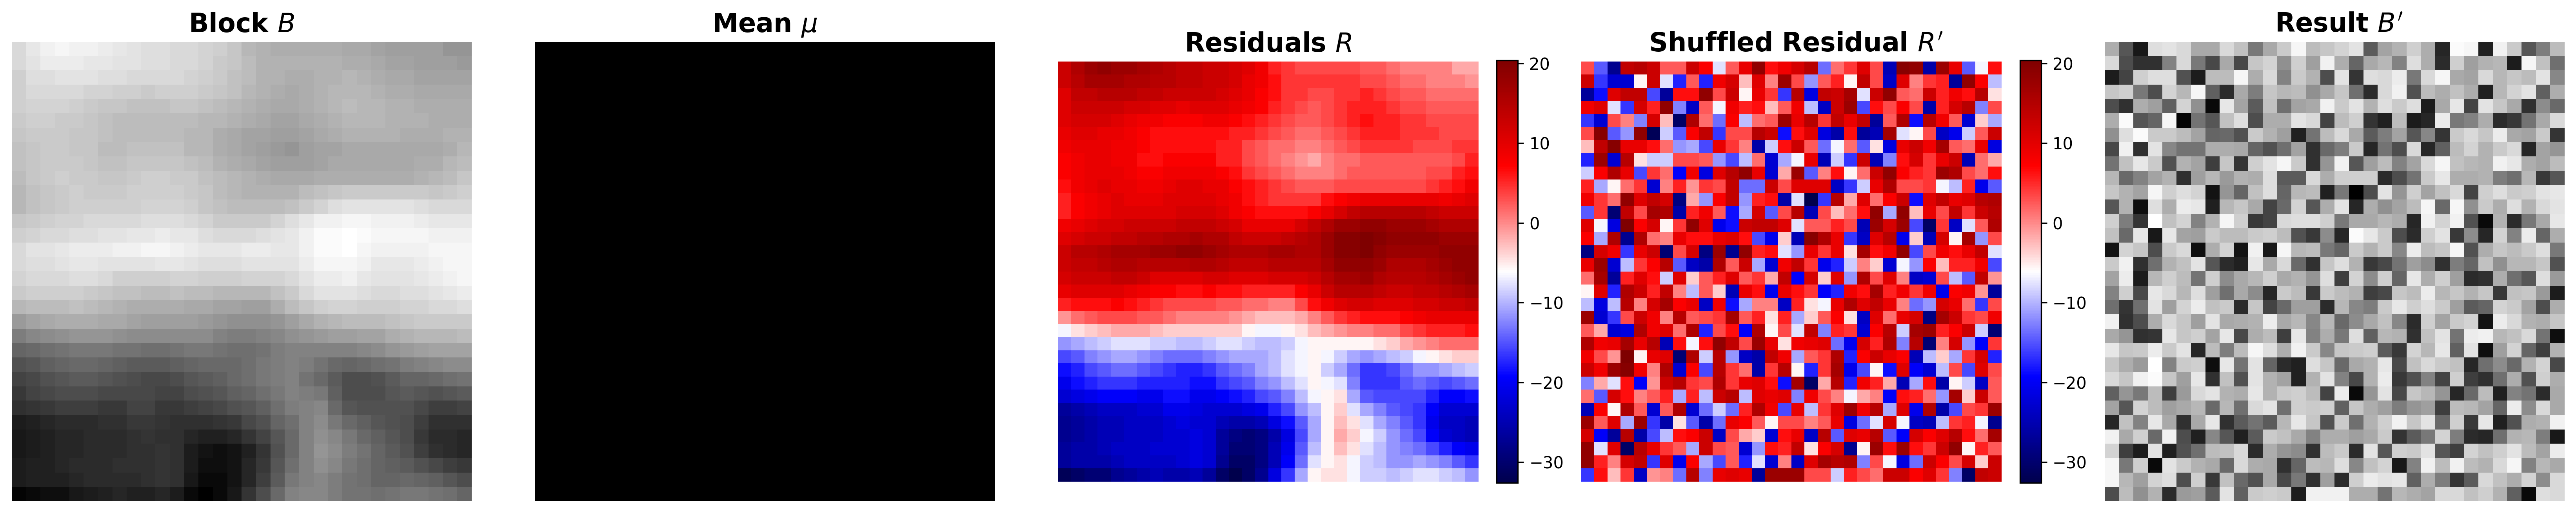


[INFO] Research diagram saved to: /content/drive/MyDrive/valid5/tpe_results/methodology_diagram.png
Encrypting and Decrypting 4 faces...


100%|██████████| 4/4 [00:03<00:00,  1.16it/s]

✅ Task complete. Diagram and results are in: /content/drive/MyDrive/valid5/tpe_results


In [ ]:
import cv2
import os
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

# =========================================================
# 1. THE SECRET MAP GENERATOR (The Chaos Map)
# =========================================================
def get_hybrid_sequence(length, x_seed, y_seed, r_seed):
    a_base, b = 1.4, 0.3
    x, y = x_seed, y_seed
    r_pop = 0.5
    seq = np.zeros(length)
    for i in range(length):
        r_pop = r_pop * np.exp(r_seed * (1 - r_pop))
        dynamic_a = a_base + (0.001 * r_pop)
        new_x = 1 - dynamic_a * (x**2) + y
        new_y = b * x
        x, y = new_x, new_y
        seq[i] = x
    return seq, x, y

# =========================================================
# 2. ENCRYPTION & DECRYPTION CORE
# =========================================================
def encrypt_tpe_reversible(img, block_size=32):
    h, w, c = img.shape
    img = cv2.resize(img, (w - (w % block_size), h - (h % block_size)))
    h, w, c = img.shape
    encrypted = img.copy().astype(np.float32)
    x_s, y_s, r_s = 0.358, 0.129, 3.91

    for ch in range(c):
        for y in range(0, h, block_size):
            for x in range(0, w, block_size):
                block = encrypted[y:y+block_size, x:x+block_size, ch]
                block_mean = np.mean(block)
                residuals = block - block_mean

                num_pixels = block.size
                weights, x_s, y_s = get_hybrid_sequence(num_pixels, x_s, y_s, r_s)
                idx = np.argsort(weights)

                shuffled_residuals = residuals.flatten()[idx]
                encrypted[y:y+block_size, x:x+block_size, ch] = (shuffled_residuals + block_mean).reshape(block_size, block_size)
    return np.clip(encrypted, 0, 255).astype(np.uint8)

def decrypt_tpe_reversible(enc_img, block_size=32):
    h, w, c = enc_img.shape
    decrypted = enc_img.copy().astype(np.float32)
    x_s, y_s, r_s = 0.358, 0.129, 3.91

    for ch in range(c):
        for y in range(0, h, block_size):
            for x in range(0, w, block_size):
                block = decrypted[y:y+block_size, x:x+block_size, ch]
                block_mean = np.mean(block)
                shuffled_residuals = block - block_mean

                num_pixels = block.size
                weights, x_s, y_s = get_hybrid_sequence(num_pixels, x_s, y_s, r_s)
                idx = np.argsort(weights)
                rev_idx = np.argsort(idx)

                original_residuals = shuffled_residuals.flatten()[rev_idx]
                decrypted[y:y+block_size, x:x+block_size, ch] = (original_residuals + block_mean).reshape(block_size, block_size)
    return np.clip(decrypted, 0, 255).astype(np.uint8)

# =========================================================
# 3. RESEARCH DIAGRAM GENERATOR
# =========================================================
def generate_research_figure(img, block_size=32, save_path="research_methodology.png"):
    """
    Creates a 5-panel diagram showing the data transformation flow.
    """
    h, w, _ = img.shape
    cy, cx = h // 2, w // 2
    block = img[cy:cy+block_size, cx:cx+block_size, 1].astype(np.float32) # Green channel

    block_mean = np.mean(block)
    invariant_mean = np.full((block_size, block_size), block_mean)
    residuals = block - block_mean

    x_s, y_s, r_s = 0.358, 0.129, 3.91
    weights, _, _ = get_hybrid_sequence(block.size, x_s, y_s, r_s)
    idx = np.argsort(weights)
    shuffled_res = residuals.flatten()[idx].reshape(block_size, block_size)

    encrypted_block = invariant_mean + shuffled_res

    fig, axes = plt.subplots(1, 5, figsize=(22, 6), dpi=300)
    titles = ["Block $B$", "Mean $\mu$", "Residuals $R$", " Shuffled Residual $R'$", " Result $B'$"]
    data = [block, invariant_mean, residuals, shuffled_res, encrypted_block]
    cmaps = ['gray', 'gray', 'seismic', 'seismic', 'gray']

    for i in range(5):
        im = axes[i].imshow(data[i], cmap=cmaps[i])
        axes[i].set_title(titles[i], fontsize=16, fontweight='bold')
        axes[i].axis('off')
        if cmaps[i] == 'seismic':
            plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    print(f"\n[INFO] Research diagram saved to: {save_path}")

# =========================
# 4. EXECUTION
# =========================
input_folder = '/content/drive/MyDrive/valid5/detected_faces'
output_folder = '/content/drive/MyDrive/valid5/tpe_results'
os.makedirs(output_folder, exist_ok=True)

face_files = sorted([f for f in os.listdir(input_folder) if f.startswith('face_') and f.lower().endswith(('.jpg', '.png', '.jpeg'))])

if not face_files:
    print("No faces found. Check your input folder path.")
else:
    # 1. Generate the Research Methodology Image
    first_img = cv2.imread(os.path.join(input_folder, face_files[0]))
    first_img = cv2.resize(first_img, (256, 256))
    generate_research_figure(first_img, save_path=os.path.join(output_folder, "methodology_diagram.png"))

    # 2. Process all faces
    print(f"Encrypting and Decrypting {len(face_files)} faces...")
    for face_name in tqdm(face_files):
        img_path = os.path.join(input_folder, face_name)
        img = cv2.imread(img_path)
        if img is None: continue

        img = cv2.resize(img, (256, 256))
        tpe_enc = encrypt_tpe_reversible(img)
        tpe_dec = decrypt_tpe_reversible(tpe_enc)

        # Optional: Save encrypted/decrypted pairs
        # cv2.imwrite(os.path.join(output_folder, "enc_" + face_name), tpe_enc)

    print(f"✅ Task complete. Diagram and results are in: {output_folder}")

<>:97: SyntaxWarning: invalid escape sequence '\m'
<>:97: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_11324/788290145.py:97: SyntaxWarning: invalid escape sequence '\m'
  titles = ["(a) Block $B$", "(b) Mean $\mu$", "(c) Residuals $R$", "(d) Shuffled $R'$", "(e) Result $B'$"]


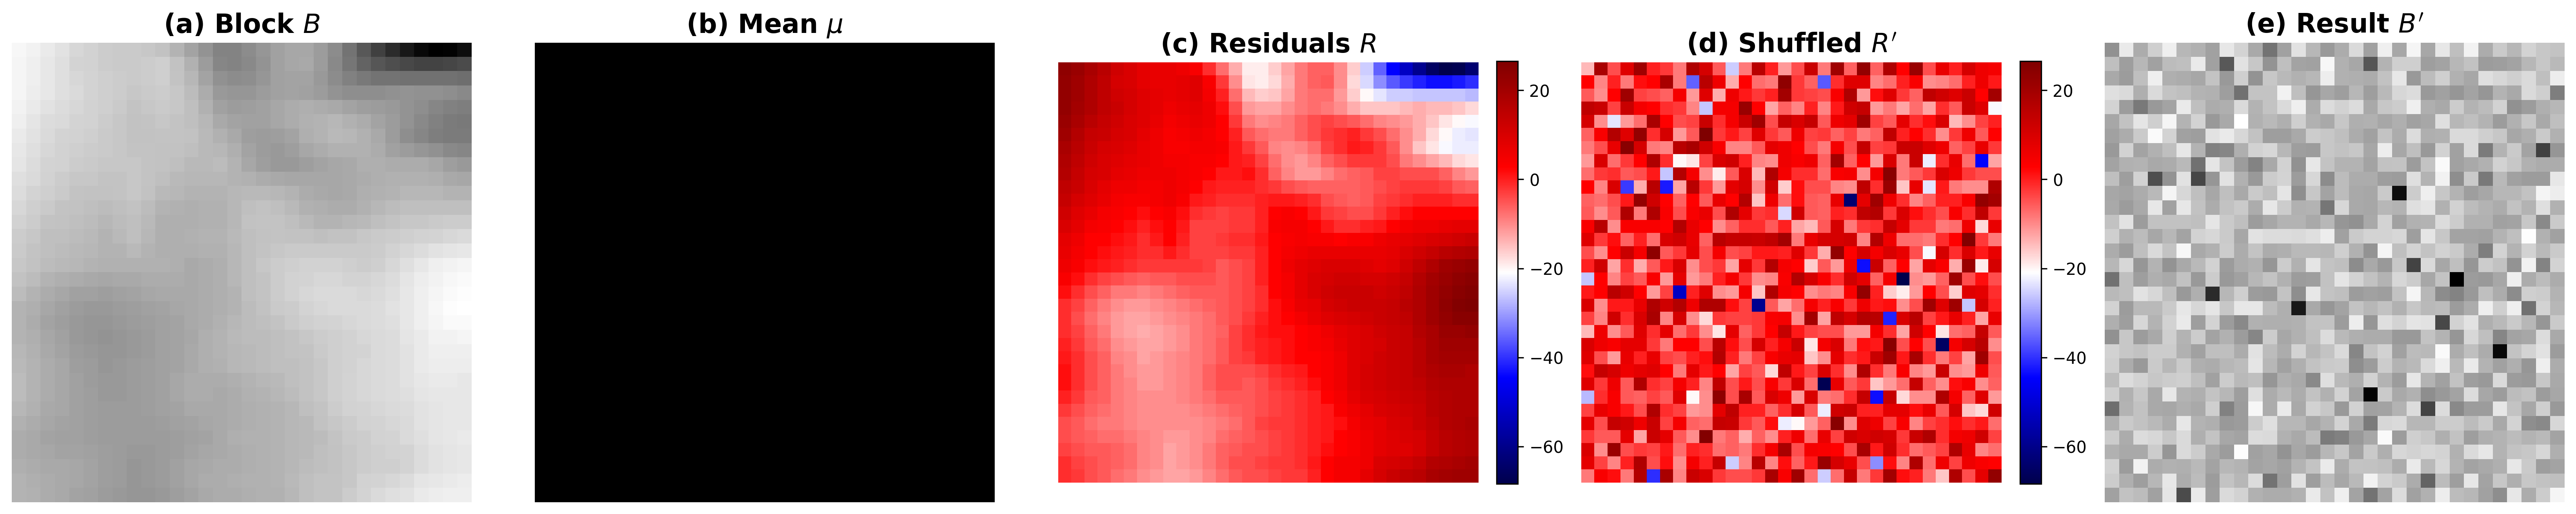


[INFO] Targeted research diagram saved to: /content/drive/MyDrive/valid5/tpe_results/methodology_diagram.png
Encrypting and Decrypting 4 faces...


100%|██████████| 4/4 [00:03<00:00,  1.14it/s]

✅ All done! Diagram and results are in: /content/drive/MyDrive/valid5/tpe_results


In [ ]:
import cv2
import os
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

# =========================================================
# 1. THE SECRET MAP GENERATOR (The Chaos Map)
# =========================================================
def get_hybrid_sequence(length, x_seed, y_seed, r_seed):
    a_base, b = 1.4, 0.3
    x, y = x_seed, y_seed
    r_pop = 0.5
    seq = np.zeros(length)
    for i in range(length):
        r_pop = r_pop * np.exp(r_seed * (1 - r_pop))
        dynamic_a = a_base + (0.001 * r_pop)
        new_x = 1 - dynamic_a * (x**2) + y
        new_y = b * x
        x, y = new_x, new_y
        seq[i] = x
    return seq, x, y

# =========================================================
# 2. ENCRYPTION & DECRYPTION CORE
# =========================================================
def encrypt_tpe_reversible(img, block_size=32):
    h, w, c = img.shape
    img = cv2.resize(img, (w - (w % block_size), h - (h % block_size)))
    h, w, c = img.shape
    encrypted = img.copy().astype(np.float32)
    x_s, y_s, r_s = 0.358, 0.129, 3.91

    for ch in range(c):
        for y in range(0, h, block_size):
            for x in range(0, w, block_size):
                block = encrypted[y:y+block_size, x:x+block_size, ch]
                block_mean = np.mean(block)
                residuals = block - block_mean

                num_pixels = block.size
                weights, x_s, y_s = get_hybrid_sequence(num_pixels, x_s, y_s, r_s)
                idx = np.argsort(weights)

                shuffled_residuals = residuals.flatten()[idx]
                encrypted[y:y+block_size, x:x+block_size, ch] = (shuffled_residuals + block_mean).reshape(block_size, block_size)
    return np.clip(encrypted, 0, 255).astype(np.uint8)

def decrypt_tpe_reversible(enc_img, block_size=32):
    h, w, c = enc_img.shape
    decrypted = enc_img.copy().astype(np.float32)
    x_s, y_s, r_s = 0.358, 0.129, 3.91

    for ch in range(c):
        for y in range(0, h, block_size):
            for x in range(0, w, block_size):
                block = decrypted[y:y+block_size, x:x+block_size, ch]
                block_mean = np.mean(block)
                shuffled_residuals = block - block_mean

                num_pixels = block.size
                weights, x_s, y_s = get_hybrid_sequence(num_pixels, x_s, y_s, r_s)
                idx = np.argsort(weights)
                rev_idx = np.argsort(idx)

                original_residuals = shuffled_residuals.flatten()[rev_idx]
                decrypted[y:y+block_size, x:x+block_size, ch] = (original_residuals + block_mean).reshape(block_size, block_size)
    return np.clip(decrypted, 0, 255).astype(np.uint8)

# =========================================================
# 3. RESEARCH DIAGRAM GENERATOR (TARGETED VERSION)
# =========================================================
def generate_targeted_figure(img, ty, tx, block_size=32, save_path="methodology_diagram.png"):
    """
    Creates a 5-panel diagram using a specific coordinate (ty, tx) to highlight
    a facial feature like an eye or nose.
    """
    # Extract the targeted block from the Green channel (usually best for grayscale detail)
    block = img[ty:ty+block_size, tx:tx+block_size, 1].astype(np.float32)

    # Mathematical Decomposition
    block_mean = np.mean(block)
    invariant_mean = np.full((block_size, block_size), block_mean)
    residuals = block - block_mean

    # Chaotic Shuffling
    x_s, y_s, r_s = 0.358, 0.129, 3.91
    weights, _, _ = get_hybrid_sequence(block.size, x_s, y_s, r_s)
    idx = np.argsort(weights)
    shuffled_res = residuals.flatten()[idx].reshape(block_size, block_size)

    # Final Re-composition
    encrypted_block = invariant_mean + shuffled_res

    # --- PLOTTING ---
    fig, axes = plt.subplots(1, 5, figsize=(22, 6), dpi=300)
    titles = ["(a) Block $B$", "(b) Mean $\mu$", "(c) Residuals $R$", "(d) Shuffled $R'$", "(e) Result $B'$"]
    data = [block, invariant_mean, residuals, shuffled_res, encrypted_block]
    cmaps = ['gray', 'gray', 'seismic', 'seismic', 'gray']

    for i in range(5):
        im = axes[i].imshow(data[i], cmap=cmaps[i])
        axes[i].set_title(titles[i], fontsize=16, fontweight='bold')
        axes[i].axis('off')
        if cmaps[i] == 'seismic':
            plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    print(f"\n[INFO] Targeted research diagram saved to: {save_path}")

# =========================
# 4. EXECUTION
# =========================
input_folder = '/content/drive/MyDrive/valid5/detected_faces'
output_folder = '/content/drive/MyDrive/valid5/tpe_results'
os.makedirs(output_folder, exist_ok=True)

# List images
face_files = sorted([f for f in os.listdir(input_folder) if f.startswith('face_') and f.lower().endswith(('.jpg', '.png', '.jpeg'))])

if not face_files:
    print("No faces found. Check your input folder path.")
else:
    # ---------------------------------------------------------
    # STEP 1: TARGETED DIAGRAM GENERATION
    # ---------------------------------------------------------
    # Pick your best sample image (e.g., face_0.jpg)
    sample_img_name = face_files[0]
    img_path = os.path.join(input_folder, sample_img_name)
    img = cv2.imread(img_path)
    img = cv2.resize(img, (256, 256))

    # ADJUST THESE COORDINATES:
    # On a 256x256 image, (110, 100) is usually near an eye.
    # Change these until Panel (a) shows exactly what you want!
    target_y, target_x = 110, 100

    generate_targeted_figure(img, target_y, target_x,
                             save_path=os.path.join(output_folder, "methodology_diagram.png"))

    # ---------------------------------------------------------
    # STEP 2: FULL DATASET PROCESSING
    # ---------------------------------------------------------
    print(f"Encrypting and Decrypting {len(face_files)} faces...")
    for face_name in tqdm(face_files):
        img_path = os.path.join(input_folder, face_name)
        img = cv2.imread(img_path)
        if img is None: continue

        img = cv2.resize(img, (256, 256))
        tpe_enc = encrypt_tpe_reversible(img)
        tpe_dec = decrypt_tpe_reversible(tpe_enc)

        # Optional: Save results
        # cv2.imwrite(os.path.join(output_folder, f"enc_{face_name}"), tpe_enc)

    print(f"✅ All done! Diagram and results are in: {output_folder}")

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
Processing 1

  0%|          | 0/1 [00:00<?, ?it/s]

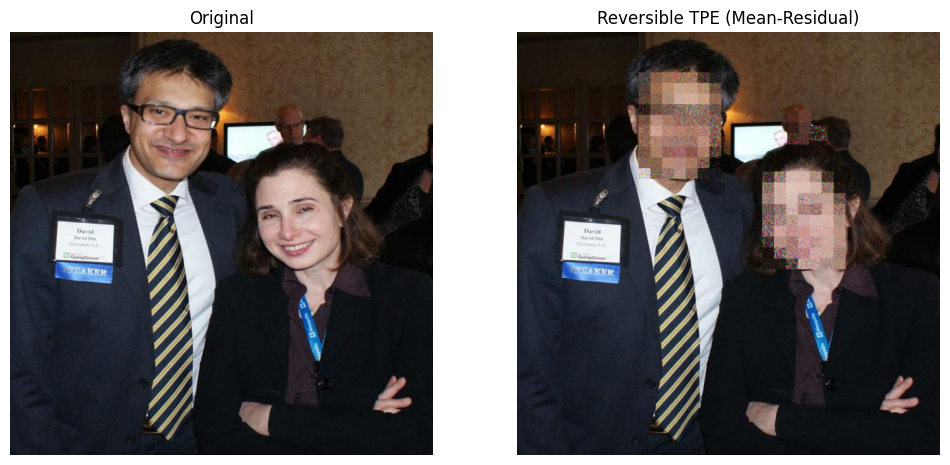

100%|██████████| 1/1 [00:02<00:00,  2.99s/it]


✅ All images processed and saved.


In [ ]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from insightface.app import FaceAnalysis

# =========================================================
# 1. NOVEL HYBRID CHAOTIC GENERATOR (Henon + Ricker)
# =========================================================
def get_hybrid_sequence(length, x_seed, y_seed, r_seed):
    a_base, b = 1.4, 0.3
    x, y, r_pop = x_seed, y_seed, 0.5
    seq = np.zeros(length)
    for i in range(length):
        r_pop = r_pop * np.exp(r_seed * (1 - r_pop))
        new_x = 1 - (a_base + 0.001 * r_pop) * (x**2) + y
        new_y = b * x
        x, y = new_x, new_y
        seq[i] = x # Raw state for permutation ranking
    return seq, x, y

# =========================================================
# 2. CORE REVERSIBLE TPE ENGINE (Mean + Residual)
# =========================================================
def encrypt_tpe_reversible(img, block_size=16):
    h, w, c = img.shape
    # Ensure ROI is divisible by block size for mathematical precision
    img = cv2.resize(img, (w - (w % block_size), h - (h % block_size)))
    h, w, c = img.shape
    encrypted = img.copy().astype(np.float32)

    x_s, y_s, r_s = 0.358, 0.129, 3.91 # Secret Keys

    for ch in range(c):
        for y in range(0, h, block_size):
            for x in range(0, w, block_size):
                block = encrypted[y:y+block_size, x:x+block_size, ch]

                # Coefficient Mapping
                mu = np.mean(block)
                residuals = block - mu

                num_pixels = block.size
                weights, x_s, y_s = get_hybrid_sequence(num_pixels, x_s, y_s, r_s)
                idx = np.argsort(weights)

                # Shuffle Residuals (Identity) but keep Mean (Thumbnail)
                shuffled_res = residuals.flatten()[idx]
                encrypted[y:y+block_size, x:x+block_size, ch] = (shuffled_res + mu).reshape(block_size, block_size)

    return np.clip(encrypted, 0, 255).astype(np.uint8)

# =========================================================
# 3. INITIALIZE MODELS & PATHS
# =========================================================
images_path = '/content/drive/MyDrive/valid5/images'
output_path = '/content/drive/MyDrive/valid5/tpe_full_results'
os.makedirs(output_path, exist_ok=True)

# Initialize RetinaFace
app = FaceAnalysis(name="buffalo_l", providers=["CPUExecutionProvider"])
app.prepare(ctx_id=0, det_size=(640, 640))

image_files = sorted([f for f in os.listdir(images_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))])

# =========================================================
# 4. FULL PROCESSING LOOP
# =========================================================
print(f"Processing {len(image_files)} images...")

for img_name in tqdm(image_files):
    full_path = os.path.join(images_path, img_name)
    img = cv2.imread(full_path)
    if img is None: continue

    h_orig, w_orig = img.shape[:2]
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    faces = app.get(img_rgb)
    final_img = img.copy()

    for face in faces:
        x1, y1, x2, y2 = face.bbox.astype(int)
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w_orig, x2), min(h_orig, y2)

        face_roi = img[y1:y2, x1:x2]
        if face_roi.size == 0: continue

        # Using block_size=16 for the 'Smooth' TPE look
        encrypted_roi = encrypt_tpe_reversible(face_roi, block_size=16)

        # Match original box size
        encrypted_roi_resized = cv2.resize(encrypted_roi, (x2 - x1, y2 - y1))

        # Substitution
        final_img[y1:y2, x1:x2] = encrypted_roi_resized

    cv2.imwrite(os.path.join(output_path, f"tpe_{img_name}"), final_img)

    if image_files.index(img_name) < 3:
        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.title("Original")
        plt.axis("off")

        plt.subplot(1, 2, 2); plt.imshow(cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB)); plt.title("Reversible TPE (Mean-Residual)")
        plt.axis("off")
        plt.show()

print(f"\n✅ All images processed and saved.")

🔄 Processing and Analyzing 4 faces...


100%|██████████| 4/4 [00:04<00:00,  1.07s/it]


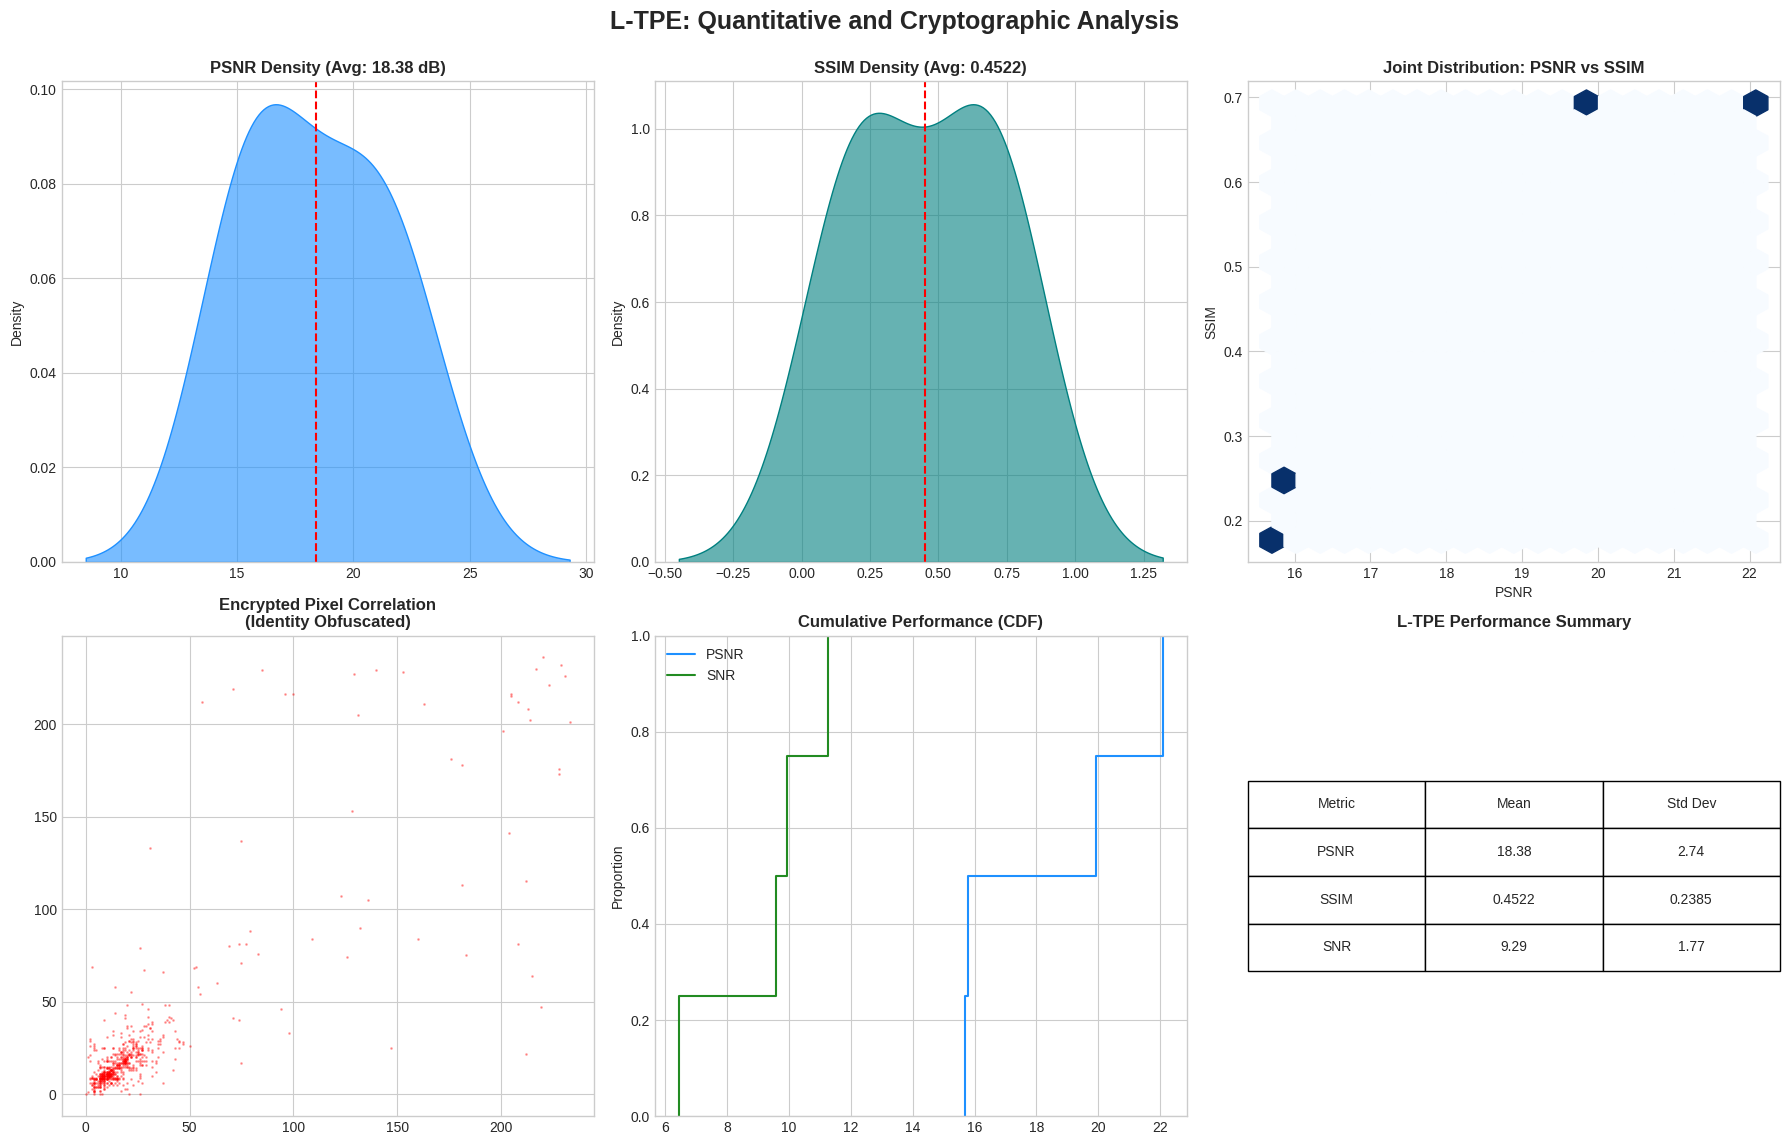

✅ Processing complete! Images saved to: /content/drive/MyDrive/valid5/tpe_results


In [ ]:
import cv2
import os
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

# ... [Keep your get_hybrid_sequence, encrypt, and decrypt functions here] ...

# =========================================================
# 4. PROCESSING & DATA COLLECTION (Integrated)
# =========================================================
input_folder = '/content/drive/MyDrive/valid5/detected_faces'
output_folder = '/content/drive/MyDrive/valid5/tpe_results'
os.makedirs(output_folder, exist_ok=True)

face_files = sorted([f for f in os.listdir(input_folder) if f.startswith('face_') and f.lower().endswith(('.jpg', '.png', '.jpeg'))])

all_psnr, all_ssim, all_snr = [], [], []

print(f"🔄 Processing and Analyzing {len(face_files)} faces...")

for face_name in tqdm(face_files):
    img_path = os.path.join(input_folder, face_name)
    img = cv2.imread(img_path)
    if img is None: continue

    # Resize for consistency
    img = cv2.resize(img, (256, 256))

    # 1. HIDE THE FACE (Encryption)
    tpe_enc = encrypt_tpe_reversible(img, block_size=32)

    # 2. SAVE THE IMAGES (Original and Encrypted)
    # This part saves the files to your Drive folder
    cv2.imwrite(os.path.join(output_folder, f"orig_{face_name}"), img)
    cv2.imwrite(os.path.join(output_folder, f"enc_{face_name}"), tpe_enc)

    # 3. CALCULATE METRICS
    p_val = psnr(img, tpe_enc)
    # Structural similarity (SSIM) requires grayscale for standard calculation
    s_val = ssim(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY),
                 cv2.cvtColor(tpe_enc, cv2.COLOR_BGR2GRAY))

    signal = np.mean(img.astype(float)**2)
    noise = np.mean((img.astype(float) - tpe_enc.astype(float))**2)
    snr_val = 10 * np.log10(signal / noise) if noise > 0 else 0

    all_psnr.append(p_val)
    all_ssim.append(s_val)
    all_snr.append(snr_val)

# =========================================================
# 5. RESEARCH DASHBOARD (Non-Bar Visualizations)
# =========================================================
plt.figure(figsize=(18, 12))
plt.style.use('seaborn-v0_8-whitegrid')

# 1. PSNR DENSITY (KDE)
plt.subplot(2, 3, 1)
sns.kdeplot(all_psnr, fill=True, color="dodgerblue", alpha=0.6)
plt.axvline(np.mean(all_psnr), color='red', linestyle='--')
plt.title(f"PSNR Density (Avg: {np.mean(all_psnr):.2f} dB)", fontweight='bold')

# 2. SSIM DENSITY (KDE)
plt.subplot(2, 3, 2)
sns.kdeplot(all_ssim, fill=True, color="teal", alpha=0.6)
plt.axvline(np.mean(all_ssim), color='red', linestyle='--')
plt.title(f"SSIM Density (Avg: {np.mean(all_ssim):.4f})", fontweight='bold')

# 3. JOINT DISTRIBUTION: PSNR vs SSIM (Hexbin)
plt.subplot(2, 3, 3)
plt.hexbin(all_psnr, all_ssim, gridsize=20, cmap='Blues')
plt.title("Joint Distribution: PSNR vs SSIM", fontweight='bold')
plt.xlabel("PSNR")
plt.ylabel("SSIM")

# 4. ADJACENT PIXEL CORRELATION (Horizontal)
# This proves structure destruction despite similar histograms
plt.subplot(2, 3, 4)
# Use the last processed encrypted image for this plot
x_enc = tpe_enc[:, :-1, 0].ravel()
y_enc = tpe_enc[:, 1:, 0].ravel()
plt.scatter(x_enc[::100], y_enc[::100], s=1, color='red', alpha=0.3)
plt.title("Encrypted Pixel Correlation\n(Identity Obfuscated)", fontweight='bold')

# 5. CUMULATIVE DISTRIBUTION (CDF)
plt.subplot(2, 3, 5)
sns.ecdfplot(all_psnr, color="dodgerblue", label="PSNR")
sns.ecdfplot(all_snr, color="forestgreen", label="SNR")
plt.title("Cumulative Performance (CDF)", fontweight='bold')
plt.legend()

# 6. STATISTICAL TABLE
plt.subplot(2, 3, 6)
plt.axis('off')
stats = [
    ["Metric", "Mean", "Std Dev"],
    ["PSNR", f"{np.mean(all_psnr):.2f}", f"{np.std(all_psnr):.2f}"],
    ["SSIM", f"{np.mean(all_ssim):.4f}", f"{np.std(all_ssim):.4f}"],
    ["SNR", f"{np.mean(all_snr):.2f}", f"{np.std(all_snr):.2f}"]
]
table = plt.table(cellText=stats, loc='center', cellLoc='center')
table.scale(1, 2.5)
plt.title("L-TPE Performance Summary", fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle("L-TPE: Quantitative and Cryptographic Analysis", fontsize=18, fontweight='bold')
plt.savefig('/content/final_research_dashboard.png', dpi=300)
plt.show()

print(f"✅ Processing complete! Images saved to: {output_folder}")